# Social Media Donation Prediction Pipeline
## Lighthouse Sanctuary — ML Pipeline (CRISP-DM Framework)

This notebook builds a complete **end-to-end machine learning pipeline** that predicts
how many donation referrals a social media post will generate — *before* the post is published.

It follows the **CRISP-DM** framework (Cross-Industry Standard Process for Data Mining),
the industry-standard approach for turning raw data into reliable predictions.

---

### The 6 CRISP-DM Phases Covered Here:

| Phase | What We Do |
|---|---|
| **1. Business Understanding** | Define the problem, success criteria, and constraints |
| **2. Data Understanding** | Explore the data to find patterns and data quality issues |
| **3. Data Preparation** | Clean, transform, and split the data for modeling |
| **4. Modeling** | Train and cross-validate 5 ensemble ML models |
| **5. Evaluation** | Tune, compare, and final-test the best model |
| **6. Deployment** | Save the model and build a reusable prediction function |

---

### Our Goal:
**Predict `donation_referrals`** — the number of donations a social media post will generate —
using only information available *before* publishing (platform, content type, timing, etc.).

This helps Lighthouse Sanctuary post more strategically without needing a marketing team.

---

### Important — Data Leakage:
"Data leakage" means accidentally giving the model information it would not have in production.
Engagement metrics (likes, shares, views, etc.) only exist *after* a post goes live — using them
would make the model look great in testing but fail completely in the real world.
All leaked columns are explicitly excluded in the Config cell below.


### Student reading guide (how this notebook fits a typical ML course)

The notebook already walks **CRISP-DM** phase-by-phase. Use this page as a **map**:

| Phase | ML concept you should recognize | What “success” means here |
|-------|-----------------------------------|---------------------------|
| 1–2 Business & data understanding | Problem definition, EDA, leakage | You can explain **why** post-publish metrics must be removed |
| 3 Data preparation | Train/validation/test split, imputation, encoding | Matrices fed to sklearn are numeric, consistent, and **no future info** |
| 4 Modeling | Supervised **regression** (target = donation count), pipelines, cross-validation | Several algorithms compared fairly with the same preprocessing |
| 5 Evaluation | Learning curves, validation curves, bias–variance | You can say in plain English if the model is over/underfitting |
| 6 Deployment | Persisting `joblib` artifacts | Another program can reload the **same** preprocessing + model |

**Regression reminder:** The model predicts a **number** (expected referrals). Errors (MAE, RMSE) are in the same units as the target. **R²** compares the model to always guessing the mean.

**If you only read one idea:** *Leakage* = any feature that would not exist at the moment you want to predict. This notebook deliberately drops engagement columns so the story stays honest.


In [ ]:
# =============================================================================
# PIPELINE CONFIGURATION
# To run this pipeline on a different dataset, only change the values in this
# cell. Everything below adapts automatically.
# =============================================================================

# Path to the CSV file (relative to this notebook's location)
DATA_PATH = "../lighthouse_csv_v7/social_media_posts.csv"

# The column we want to predict
TARGET_COL = "donation_referrals"

# Fraction of data held back for the final honest test (0.2 = 20%)
TEST_SIZE = 0.2

# Random seed — ensures identical results every run
RANDOM_STATE = 27

# =============================================================================
# COLUMNS TO EXCLUDE
# =============================================================================

# POST-PUBLISH LEAKAGE COLUMNS
# These metrics only exist AFTER a post has been published and people have
# seen it. Since we want to predict BEFORE posting, we cannot use them.
LEAKAGE_COLS = [
    "impressions",                # Times the post was displayed — only known after posting
    "reach",                      # Unique viewers — only known after posting
    "likes",                      # Reactions — only known after posting
    "comments",                   # Comments — only known after posting
    "shares",                     # Shares/retweets — only known after posting
    "saves",                      # Saves/bookmarks — only known after posting
    "click_throughs",             # Website clicks from the post — only known after posting
    "video_views",                # Video view count — only known after posting
    "engagement_rate",            # (likes+comments+shares)/reach — only known after posting
    "profile_visits",             # Profile visits attributed to this post — only after posting
    "watch_time_seconds",         # YouTube total watch time — only known after posting
    "avg_view_duration_seconds",  # YouTube avg watch duration — only known after posting
    "forwards",                   # WhatsApp forwards — only known after posting
    "estimated_donation_value_php",  # DIRECT LEAKAGE: this is the target in a different unit
]

# NON-PREDICTIVE IDENTIFIER AND FREE-TEXT COLUMNS
# These are IDs, URLs, or raw text — no learnable patterns for the model
DROP_COLS = [
    "post_id",          # Row number — no predictive value
    "platform_post_id", # Platform-internal ID — no predictive value
    "post_url",         # Link to the post — no pattern the model can learn
    "caption",          # Full caption text — complex NLP; handled by caption_length + sentiment_tone
    "hashtags",         # Raw hashtag text — handled by num_hashtags
    "created_at",       # Full timestamp — already captured by day_of_week and post_hour
]


# Phase 1: Business Understanding

## Who Are We Building This For?

**Lighthouse Sanctuary** is a US-based nonprofit (501(c)(3)) that operates safe homes for girls
who are survivors of sexual abuse and trafficking in the Philippines. The organization depends
*entirely* on donations to fund operations.

A new organization modeled after Lighthouse Sanctuary is being built from scratch. This ML pipeline
is one piece of the technology stack powering that organization.

---

## The Problem

Social media is the organization's **primary channel for reaching potential donors**, but the
founding team has no marketing background. They struggle with questions like:

- What kind of posts should we create?
- Which platform reaches the most donors?
- What time of day should we post?
- What content actually leads to **donations** — not just likes?

They post sporadically and cannot easily connect social media activity to real donation outcomes.

---

## Our ML Solution

We build a model that predicts **how many donation referrals a post will generate**, using only
features available *before* the post is published:

| Pre-Publish Feature | Examples |
|---|---|
| Platform | Facebook, Instagram, TikTok, LinkedIn, YouTube, Twitter, WhatsApp |
| Content type | Impact Story, Fundraising Appeal, Educational Content, Campaign |
| Timing | Day of week, Hour of day |
| Content details | Sentiment tone, call-to-action, hashtag count, caption length |
| Promotion | Whether the post is boosted + budget |
| Audience | Follower count at post time |

---

## Success Metrics

| Metric | What It Measures |
|---|---|
| **MAE** (Mean Absolute Error) | On average, how many donations off is our prediction? |
| **RMSE** (Root Mean Squared Error) | Like MAE but penalizes large errors more heavily |
| **R²** (R-squared) | What fraction of the variation in donations does the model explain? (0 = no better than guessing the mean; 1 = perfect) |

---

## Key Constraint: No Data Leakage

The model must *only* use pre-publish features. Post-publish engagement metrics
(likes, shares, views, click-throughs, etc.) are excluded. `estimated_donation_value_php`
is also excluded because it is directly derived from the target — using it would make
the model look perfect in testing but fail completely in production.


# Phase 2: Data Understanding

Before training a model, we explore the data to understand:
- What columns exist and what types of data they contain
- How the target variable (`donation_referrals`) is distributed
- What patterns in platform, timing, and content are correlated with donations
- Whether there are any data quality issues to address

Think of this as studying the material before building something from it —
the more we understand the data, the better our model and decisions will be.


In [ ]:
# =============================================================================
# PHASE 2, STEP 1: Import tools and load the dataset
# =============================================================================

# Suppress minor warnings so the output stays readable
import warnings
warnings.filterwarnings("ignore")

# numpy — math and array operations (the backbone of numerical Python)
import numpy as np

# pandas — load and manipulate tabular data (like a spreadsheet in Python)
import pandas as pd

# matplotlib and seaborn — for creating charts and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent, clean visual style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# --- Load the CSV into a DataFrame ---
# A DataFrame is like a spreadsheet: rows = posts, columns = features/metrics
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows (posts)  x  {df.shape[1]} columns")
print()
print("First 5 rows:")
df.head()


Dataset loaded successfully!
Shape: 812 rows (posts)  x  39 columns

First 5 rows:


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


In [ ]:
# =============================================================================
# PHASE 2, STEP 2: Check data types and identify missing values
# =============================================================================

# Show the data type stored in each column
print("=== Column Data Types ===")
print(df.dtypes.to_string())
print()

# Count how many values are empty (null/NaN) in each column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(1)
missing_report = (
    pd.DataFrame({"Missing Count": missing_count, "Missing %": missing_pct})
    .query("`Missing Count` > 0")
    .sort_values("Missing %", ascending=False)
)

print("=== Columns With Missing Values ===")
if missing_report.empty:
    print("  No missing values found.")
else:
    print(missing_report.to_string())

print()
print("NOTE: All missing values here are EXPECTED — they are not data errors.")
print("  boost_budget_php            → null when is_boosted = False (no money spent)")
print("  video_views                 → null for non-Video/Reel posts")
print("  watch_time_seconds          → null for non-YouTube posts")
print("  avg_view_duration_seconds   → null for non-YouTube posts")
print("  subscriber_count_at_post    → null for non-YouTube posts")
print("  forwards                    → null for non-WhatsApp posts")
print("  campaign_name               → null when post is not part of a campaign")
print("  call_to_action_type         → null when has_call_to_action = False")


=== Column Data Types ===
post_id                           int64
platform                            str
platform_post_id                    str
post_url                            str
created_at                          str
day_of_week                         str
post_hour                         int64
post_type                           str
media_type                          str
caption                             str
hashtags                            str
num_hashtags                      int64
mentions_count                    int64
has_call_to_action                 bool
call_to_action_type                 str
content_topic                       str
sentiment_tone                      str
caption_length                    int64
features_resident_story            bool
campaign_name                       str
is_boosted                         bool
boost_budget_php                float64
impressions                       int64
reach                             int64
likes         

=== Distribution of 'donation_referrals' ===
  Total posts:             812
  Posts with 0 donations:  290  (35.7%)
  Posts with 1+ donations: 522  (64.3%)
  Minimum:                 0
  Maximum:                 458
  Mean:                    12.8
  Median:                  2
  Std deviation:           31.3



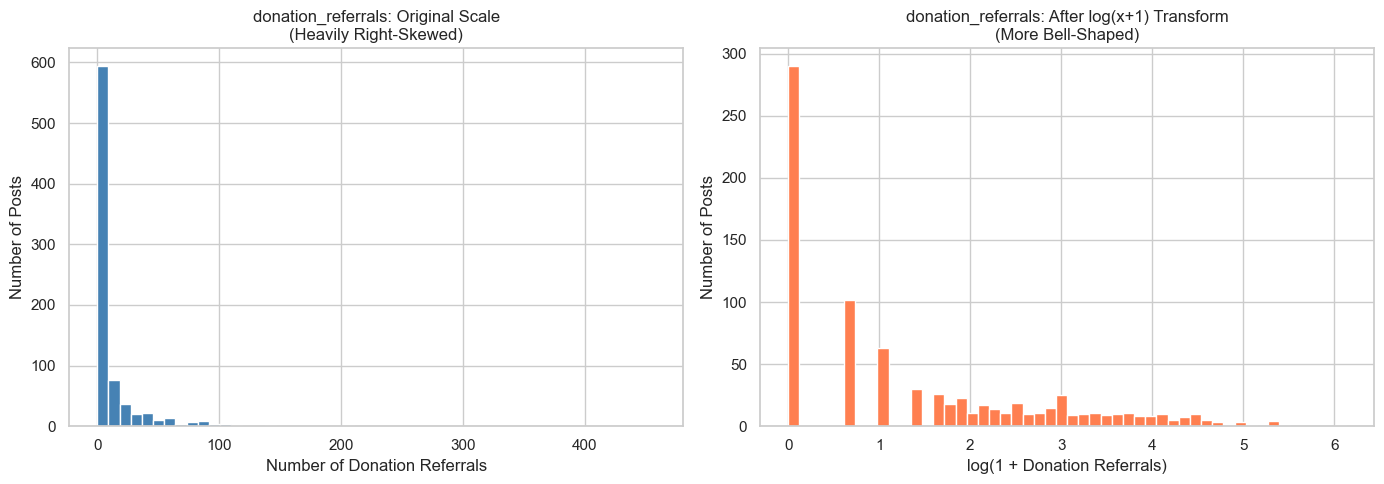

WHY LOG TRANSFORM?
  The original data is heavily right-skewed (median=2, max=458).
  Without transformation, extreme outliers overwhelm the model.
  log(y+1) compresses the scale so all posts are treated more fairly.
  At prediction time, we reverse this: expm1(prediction) = e^prediction - 1.


In [ ]:
# =============================================================================
# PHASE 2, STEP 3: Explore the target variable — what are we predicting?
# =============================================================================

target = df[TARGET_COL]

print(f"=== Distribution of '{TARGET_COL}' ===")
print(f"  Total posts:             {len(target):,}")
print(f"  Posts with 0 donations:  {(target == 0).sum():,}  ({(target == 0).mean()*100:.1f}%)")
print(f"  Posts with 1+ donations: {(target > 0).sum():,}  ({(target > 0).mean()*100:.1f}%)")
print(f"  Minimum:                 {target.min()}")
print(f"  Maximum:                 {target.max()}")
print(f"  Mean:                    {target.mean():.1f}")
print(f"  Median:                  {target.median():.0f}")
print(f"  Std deviation:           {target.std():.1f}")
print()

# --- Visualize both the raw and log-transformed target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Original scale — shows how skewed the data is.
# "Right-skewed" means most posts have low values, but a few have very high counts.
axes[0].hist(target, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("donation_referrals: Original Scale\n(Heavily Right-Skewed)", fontsize=12)
axes[0].set_xlabel("Number of Donation Referrals")
axes[0].set_ylabel("Number of Posts")

# RIGHT: After log(x+1) transform — the data becomes more "bell-shaped."
# Models learn better from bell-shaped distributions because the values are
# more evenly spread. We add 1 before log because log(0) is mathematically undefined.
axes[1].hist(np.log1p(target), bins=50, color="coral", edgecolor="white")
axes[1].set_title("donation_referrals: After log(x+1) Transform\n(More Bell-Shaped)", fontsize=12)
axes[1].set_xlabel("log(1 + Donation Referrals)")
axes[1].set_ylabel("Number of Posts")

plt.tight_layout()
plt.show()

print("WHY LOG TRANSFORM?")
print("  The original data is heavily right-skewed (median=2, max=458).")
print("  Without transformation, extreme outliers overwhelm the model.")
print("  log(y+1) compresses the scale so all posts are treated more fairly.")
print("  At prediction time, we reverse this: expm1(prediction) = e^prediction - 1.")


=== Donation Performance by Platform ===
           Posts  Avg_Donations  Median_Donations  Total_Donations
platform                                                          
WhatsApp      93          23.10               2.0             2148
YouTube       71          19.96               4.0             1417
TikTok        89          19.55               4.0             1740
Instagram    164          11.58               2.0             1899
Facebook     199          10.93               1.0             2176
Twitter      117           5.74               2.0              672
LinkedIn      79           4.28               0.0              338



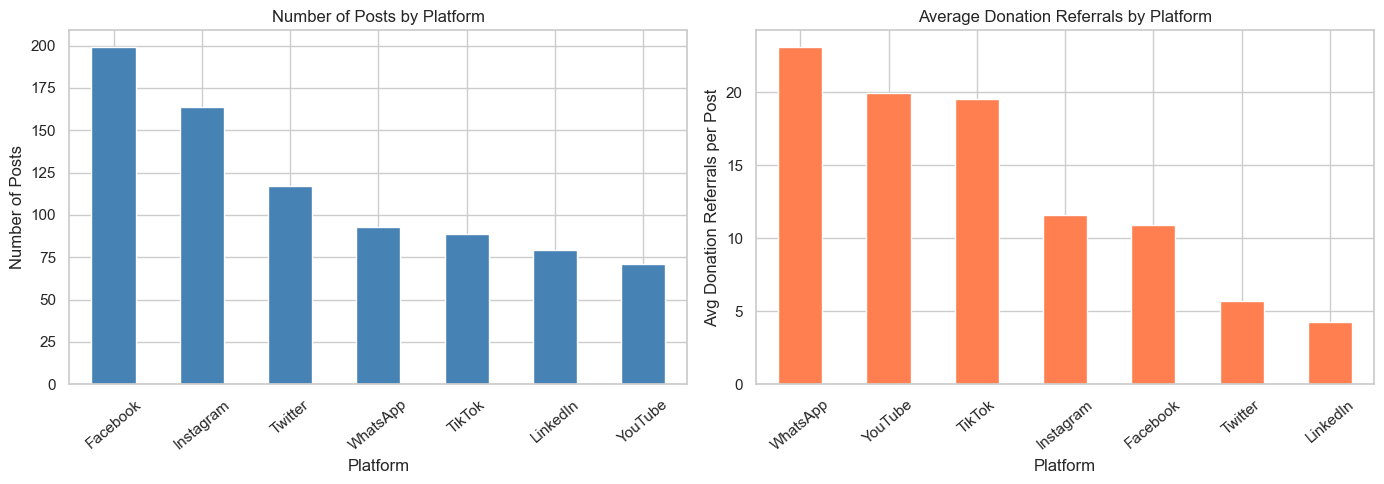

In [ ]:
# =============================================================================
# PHASE 2, STEP 4: How does each social media platform perform for donations?
# =============================================================================

platform_stats = (
    df.groupby("platform")[TARGET_COL]
    .agg(Posts="count", Avg_Donations="mean", Median_Donations="median", Total_Donations="sum")
    .sort_values("Avg_Donations", ascending=False)
    .round(2)
)

print("=== Donation Performance by Platform ===")
print(platform_stats.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: How many posts per platform?
df["platform"].value_counts().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Number of Posts by Platform")
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("Number of Posts")
axes[0].tick_params(axis="x", rotation=40)

# RIGHT: Which platform generates the most donations on average?
platform_stats["Avg_Donations"].plot(
    kind="bar", ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("Average Donation Referrals by Platform")
axes[1].set_xlabel("Platform")
axes[1].set_ylabel("Avg Donation Referrals per Post")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()


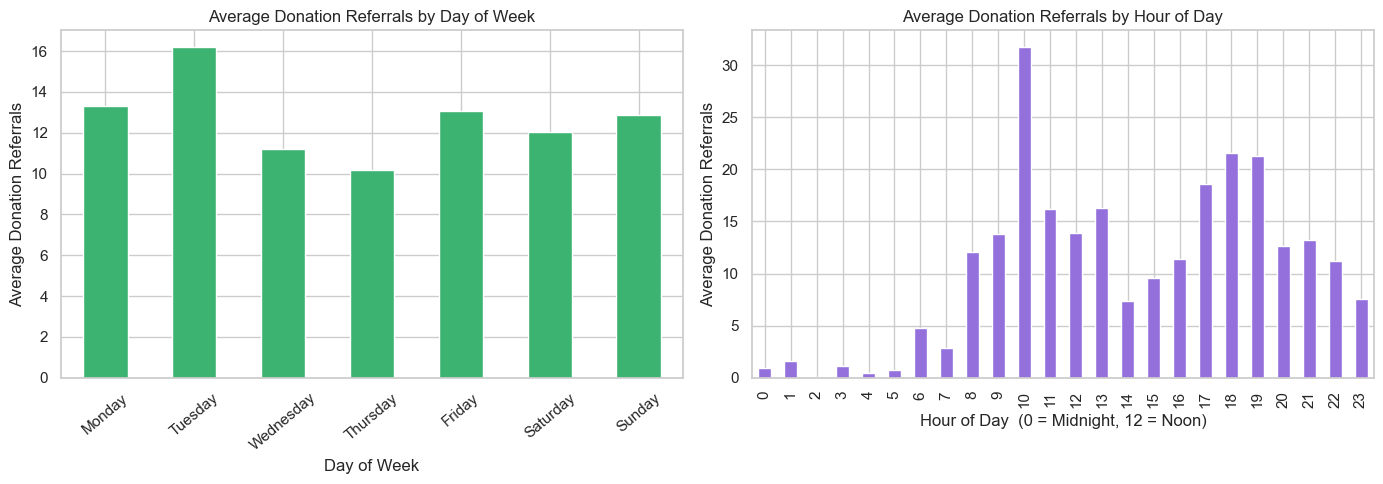

These charts show raw averages — not model predictions.
The model will learn these timing patterns automatically during training.


In [ ]:
# =============================================================================
# PHASE 2, STEP 5: Do the day and hour of posting affect donations?
# =============================================================================

# Put days in logical order (Mon → Sun) instead of alphabetical
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_avg = (
    df.groupby("day_of_week")[TARGET_COL].mean()
    .reindex(day_order)
    .fillna(0)
)

# Average donations by hour (0 = midnight, 12 = noon, 23 = 11pm)
hour_avg = df.groupby("post_hour")[TARGET_COL].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_avg.plot(kind="bar", ax=axes[0], color="mediumseagreen", edgecolor="white")
axes[0].set_title("Average Donation Referrals by Day of Week")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Donation Referrals")
axes[0].tick_params(axis="x", rotation=40)

hour_avg.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="white")
axes[1].set_title("Average Donation Referrals by Hour of Day")
axes[1].set_xlabel("Hour of Day  (0 = Midnight, 12 = Noon)")
axes[1].set_ylabel("Average Donation Referrals")

plt.tight_layout()
plt.show()

print("These charts show raw averages — not model predictions.")
print("The model will learn these timing patterns automatically during training.")


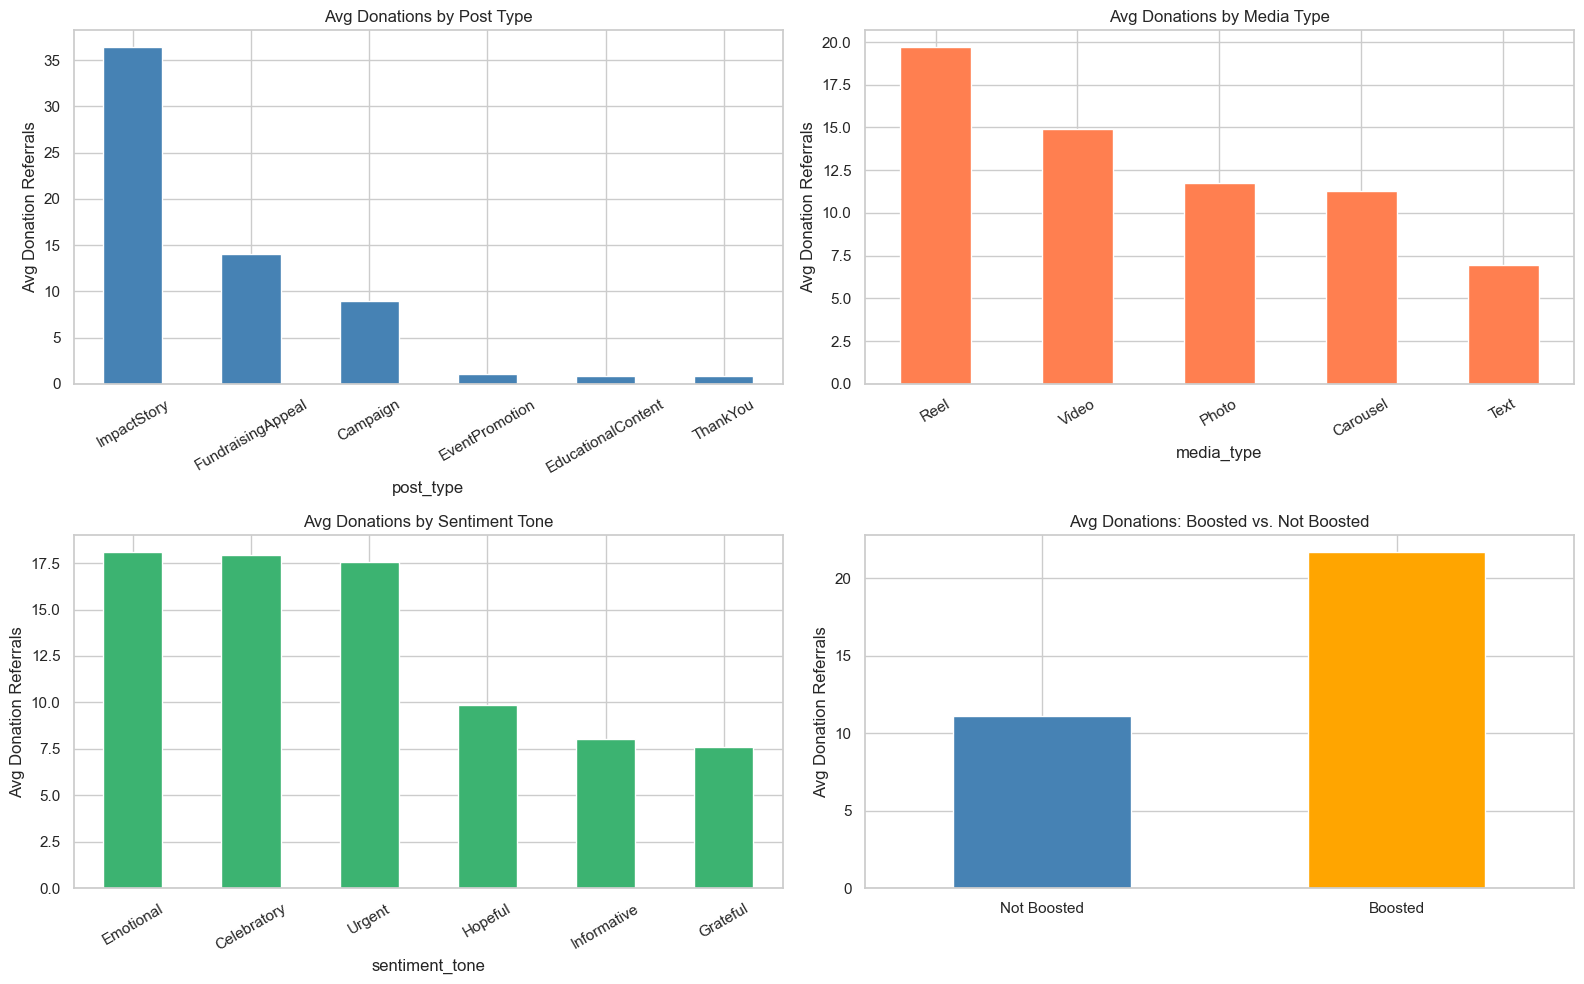

Average donations by call-to-action presence:
has_call_to_action
No Call-to-Action     14.291536
Has Call-to-Action    11.827586


In [ ]:
# =============================================================================
# PHASE 2, STEP 6: Does content type, media format, or sentiment affect donations?
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Post Type — what category of content is this?
post_type_avg = df.groupby("post_type")[TARGET_COL].mean().sort_values(ascending=False)
post_type_avg.plot(kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Avg Donations by Post Type")
axes[0, 0].set_ylabel("Avg Donation Referrals")
axes[0, 0].tick_params(axis="x", rotation=30)

# Media Type — photo, video, carousel, text, or reel?
media_avg = df.groupby("media_type")[TARGET_COL].mean().sort_values(ascending=False)
media_avg.plot(kind="bar", ax=axes[0, 1], color="coral", edgecolor="white")
axes[0, 1].set_title("Avg Donations by Media Type")
axes[0, 1].set_ylabel("Avg Donation Referrals")
axes[0, 1].tick_params(axis="x", rotation=30)

# Sentiment Tone — the emotional tone of the post
sentiment_avg = df.groupby("sentiment_tone")[TARGET_COL].mean().sort_values(ascending=False)
sentiment_avg.plot(kind="bar", ax=axes[1, 0], color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Avg Donations by Sentiment Tone")
axes[1, 0].set_ylabel("Avg Donation Referrals")
axes[1, 0].tick_params(axis="x", rotation=30)

# Boosted vs Not Boosted — does paying for reach help?
boost_avg = df.groupby("is_boosted")[TARGET_COL].mean()
boost_avg.index = ["Not Boosted", "Boosted"]
boost_avg.plot(kind="bar", ax=axes[1, 1], color=["steelblue", "orange"], edgecolor="white")
axes[1, 1].set_title("Avg Donations: Boosted vs. Not Boosted")
axes[1, 1].set_ylabel("Avg Donation Referrals")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Does including a call-to-action button make a difference?
cta_avg = df.groupby("has_call_to_action")[TARGET_COL].mean()
print("Average donations by call-to-action presence:")
print(cta_avg.rename({False: "No Call-to-Action", True: "Has Call-to-Action"}).to_string())


# Phase 3: Data Preparation

Now that we understand the data, we prepare it for machine learning.

Think of this like preparing ingredients before cooking:
- Remove ingredients that would spoil the dish (leaked columns, identifiers)
- Convert everything to a consistent format (scale numbers, encode text categories)
- Divide the data into a "study set" (training) and a sealed "exam set" (test)

**Steps in this phase:**
1. Fill `boost_budget_php` null → 0 for non-boosted posts
2. Fill `subscriber_count_at_post` null → 0 for non-YouTube posts
3. Convert boolean columns to integers (0 / 1)
4. Remove all leakage and non-predictive columns
5. Apply `log(y+1)` to the target variable
6. Auto-detect numeric vs. categorical features
7. Build a `ColumnTransformer` preprocessing pipeline
8. Split data: 80% training, 20% test (test set frozen until Phase 5)


In [ ]:
# =============================================================================
# PHASE 3, STEP 1: Clean the data and build the feature set
# =============================================================================

# Make a copy so the original DataFrame is preserved for reference
df_clean = df.copy()

# --- Fill meaningful nulls BEFORE removing columns ---

# boost_budget_php is null for non-boosted posts — null here means "zero budget," not "unknown."
# We make this explicit so the model can learn "no budget = 0."
df_clean["boost_budget_php"] = df_clean["boost_budget_php"].fillna(0)

# subscriber_count_at_post is only populated for YouTube posts.
# For all other platforms, the YouTube subscriber count is irrelevant — fill with 0.
df_clean["subscriber_count_at_post"] = df_clean["subscriber_count_at_post"].fillna(0)

# --- Convert boolean columns to integers (0 = False, 1 = True) ---
# Models work with numbers. Converting True/False to 1/0 makes booleans
# usable as numeric features alongside columns like post_hour or num_hashtags.
bool_cols = df_clean.select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

if bool_cols:
    print(f"Converted boolean columns to 0/1: {bool_cols}")

# --- Build the list of columns to remove ---
# We remove: leakage columns + identifier/text columns + the target itself
all_remove = set(LEAKAGE_COLS + DROP_COLS + [TARGET_COL])

# Keep only valid pre-publish features
feature_cols = [col for col in df_clean.columns if col not in all_remove]

print("\n=== Valid Pre-Publish Feature Set ===")
for col in feature_cols:
    dtype = df_clean[col].dtype
    n_unique = df_clean[col].nunique()
    print(f"  {col:<35} type={str(dtype):<10}  unique values={n_unique}")

print(f"\nTotal features available: {len(feature_cols)}")

# --- Define X (inputs) and y (target) ---
X = df_clean[feature_cols].copy()
y = df_clean[TARGET_COL].copy()

# --- Apply log(y+1) transform to the target ---
# donation_referrals is right-skewed (median=2, max=458).
# The log transform compresses the scale so extreme values don't dominate training.
# np.log1p(x) = log(1+x)  — the +1 prevents log(0) which is undefined.
# We reverse this with np.expm1(x) = e^x - 1 when reporting predictions.
y_log = np.log1p(y)

print(f"\nTarget '{TARGET_COL}' transformation:")
print(f"  Original — min: {y.min()},  max: {y.max()},  mean: {y.mean():.1f}")
print(f"  log(y+1) — min: {y_log.min():.2f}, max: {y_log.max():.2f}, mean: {y_log.mean():.2f}")


Converted boolean columns to 0/1: ['has_call_to_action', 'features_resident_story', 'is_boosted']

=== Valid Pre-Publish Feature Set ===
  platform                            type=str         unique values=7
  day_of_week                         type=str         unique values=7
  post_hour                           type=int64       unique values=24
  post_type                           type=str         unique values=6
  media_type                          type=str         unique values=5
  num_hashtags                        type=int64       unique values=6
  mentions_count                      type=int64       unique values=4
  has_call_to_action                  type=int64       unique values=2
  call_to_action_type                 type=str         unique values=4
  content_topic                       type=str         unique values=9
  sentiment_tone                      type=str         unique values=6
  caption_length                      type=int64       unique values=124
  featur

In [ ]:
# =============================================================================
# PHASE 3, STEP 2: Build the preprocessing pipeline and split the data
# =============================================================================

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    learning_curve,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# --- Auto-detect numeric and categorical columns ---
# Numbers like post_hour, num_hashtags, follower_count, etc. need different
# treatment than text categories like platform, post_type, sentiment_tone, etc.
numeric_cols     = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}):")
print(f"  {numeric_cols}")
print(f"\nCategorical features ({len(categorical_cols)}):")
print(f"  {categorical_cols}")

# --- Preprocessing pipeline for NUMERIC columns ---
# Step 1 — SimpleImputer: fill any remaining nulls with the median value of that column.
# Step 2 — StandardScaler: rescale all numbers to mean=0, std=1.
#
# WHY SCALE? follower_count ranges from 360-2489; num_hashtags ranges from 0-20.
# Without scaling, the model might unfairly weight large-numbered features just
# because their numbers are bigger. Scaling puts all features on equal footing.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# --- Preprocessing pipeline for CATEGORICAL columns ---
# Step 1 — SimpleImputer: fill nulls with the most common value (e.g., no campaign name).
# Step 2 — OneHotEncoder: convert category names to 0/1 columns.
#
# WHY ONE-HOT ENCODE? Models work with numbers, not text. "Facebook" becomes [1,0,0,...],
# "Instagram" becomes [0,1,0,...], etc. Each category gets its own binary column.
# handle_unknown="ignore" means new categories in future data won't crash the model.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Combine both into one ColumnTransformer ---
# This automatically applies the right transformer to each column type.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

# --- Cross-Validation Strategy ---
# KFold splits the training data into 5 "folds" (equal chunks).
# The model trains on 4 folds and is tested on the 5th — this repeats 5 times,
# each time using a different fold as the test. We average all 5 scores.
# This is like taking 5 different practice exams and averaging your grade.
# It is far more reliable than evaluating on a single split.
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Train / Test Split ---
# 80% → training set (the model learns from this, and we run CV on this)
# 20% → test set    (completely frozen — only used once in Phase 5, Step 6)
# IMPORTANT: Splitting on y_log (the transformed target) to keep the transform consistent.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"\nData split complete:")
print(f"  Training set:  {X_train.shape[0]:,} posts  (80% — used for learning + cross-validation)")
print(f"  Test set:      {X_test.shape[0]:,} posts   (20% — frozen until Phase 5, Step 6)")
print(f"  Features per post after preprocessing: will expand due to one-hot encoding")


Numeric features (10):
  ['post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'caption_length', 'features_resident_story', 'is_boosted', 'boost_budget_php', 'follower_count_at_post', 'subscriber_count_at_post']

Categorical features (8):
  ['platform', 'day_of_week', 'post_type', 'media_type', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'campaign_name']

Data split complete:
  Training set:  649 posts  (80% — used for learning + cross-validation)
  Test set:      163 posts   (20% — frozen until Phase 5, Step 6)
  Features per post after preprocessing: will expand due to one-hot encoding


# Phase 4: Modeling

We train and compare **5 ensemble machine learning models**.

An **ensemble** model combines many smaller models to produce a better collective result —
similar to how asking 100 people for directions is more reliable than asking just one person.

### The 5 Models:

| Model | Core Idea |
|---|---|
| **Random Forest** | Builds hundreds of decision trees on random data subsets and averages their predictions |
| **Gradient Boosting** | Builds trees one at a time, each correcting the mistakes of the previous |
| **Extra Trees** | Like Random Forest but with added randomization in how each split is chosen |
| **AdaBoost** | Gives harder examples more weight each round so the model focuses on difficult cases |
| **Bagging** | Trains many copies of a base model on random data samples and averages their results |

### Evaluation: 5-Fold Cross-Validation

Each model is evaluated **5 times** on different portions of the training data.
We average the 5 scores to get a reliable performance estimate, and check the
**standard deviation** — a low std means the model performs consistently.

### Metrics:
- **MAE** — average prediction error (in log-donation units)
- **RMSE** — like MAE but more sensitive to large errors
- **R²** — percentage of variation in donations the model explains


In [ ]:
# =============================================================================
# PHASE 4: Define and cross-validate 5 ensemble models
# =============================================================================
# STUDENT NOTE: "Ensemble" = many weak learners combined (averaged or boosted) to reduce
# variance and capture nonlinearities. sklearn Pipelines ensure scalers/encoders learn
# ONLY from training folds inside CV—no peeking at validation rows.

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
)

# --- Define the 5 ensemble models ---
# Each model is wrapped in a Pipeline that includes the preprocessor.
# This means preprocessing (scaling, encoding) happens automatically inside
# each model — it cannot be accidentally applied twice or skipped.
models = {
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,       # Build 100 decision trees
            random_state=RANDOM_STATE,
            n_jobs=-1,              # Use all available CPU cores (faster)
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "AdaBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", AdaBoostRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Bagging": Pipeline([
        ("preprocessor", preprocessor),
        ("model", BaggingRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

# --- Define scoring metrics ---
# sklearn uses "negative" error metrics so that higher is always "better."
# We flip the sign back when reporting.
scoring = {
    "neg_MAE": "neg_mean_absolute_error",
    "neg_MSE": "neg_mean_squared_error",
    "R2":      "r2",
}

# --- Cross-validate all 5 models ---
print("Running 5-fold cross-validation on all 5 models...")
print("Each model will be trained and evaluated 5 times — this may take a few minutes.\n")

cv_results = {}

for name, pipeline in models.items():
    print(f"  Evaluating: {name}...", end=" ", flush=True)
    results = cross_validate(
        pipeline,
        X_train, y_train,
        cv=kf,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_results[name] = results

    # Quick preview of average scores across the 5 folds
    mae  = -np.mean(results["test_neg_MAE"])
    rmse =  np.sqrt(-np.mean(results["test_neg_MSE"]))
    r2   =  np.mean(results["test_R2"])
    print(f"Done  |  MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}")

print("\nAll models evaluated.")
print("NOTE: Metrics are on the log(y+1) scale — lower MAE/RMSE is better, higher R2 is better.")


Running 5-fold cross-validation on all 5 models...
Each model will be trained and evaluated 5 times — this may take a few minutes.

  Evaluating: Random Forest... Done  |  MAE: 0.6080  RMSE: 0.8070  R2: 0.6874
  Evaluating: Gradient Boosting... Done  |  MAE: 0.5737  RMSE: 0.7543  R2: 0.7278
  Evaluating: Extra Trees... Done  |  MAE: 0.6802  RMSE: 0.9103  R2: 0.6026
  Evaluating: AdaBoost... Done  |  MAE: 0.8451  RMSE: 0.9809  R2: 0.5375
  Evaluating: Bagging... Done  |  MAE: 0.6088  RMSE: 0.8080  R2: 0.6866

All models evaluated.
NOTE: Metrics are on the log(y+1) scale — lower MAE/RMSE is better, higher R2 is better.


# Phase 5: Evaluation & Tuning

We now analyze the models in depth:

1. **Learning Curves** — Does the model need more data? Is it overfitting?
2. **Validation Curves** — What hyperparameter values work best?
3. **GridSearchCV** — Exhaustively search hyperparameter combinations for Random Forest
4. **RandomizedSearchCV** — Efficiently sample the search space for Gradient Boosting
5. **Comparison Table** — Rank all models (including tuned versions) side by side
6. **Final Test Evaluation** — One honest score on unseen data
7. **Feature Importance** — Which features drive donation predictions?

---

### Key Vocabulary:
| Term | Plain-English Meaning |
|---|---|
| **Overfitting** | Model memorizes training data but fails on new data (like memorizing answers without understanding the material) |
| **Underfitting** | Model is too simple to learn the patterns in the data |
| **Hyperparameters** | Settings chosen *before* training (e.g., how many trees to build) |
| **Tuning** | Systematically searching for the best hyperparameter values |


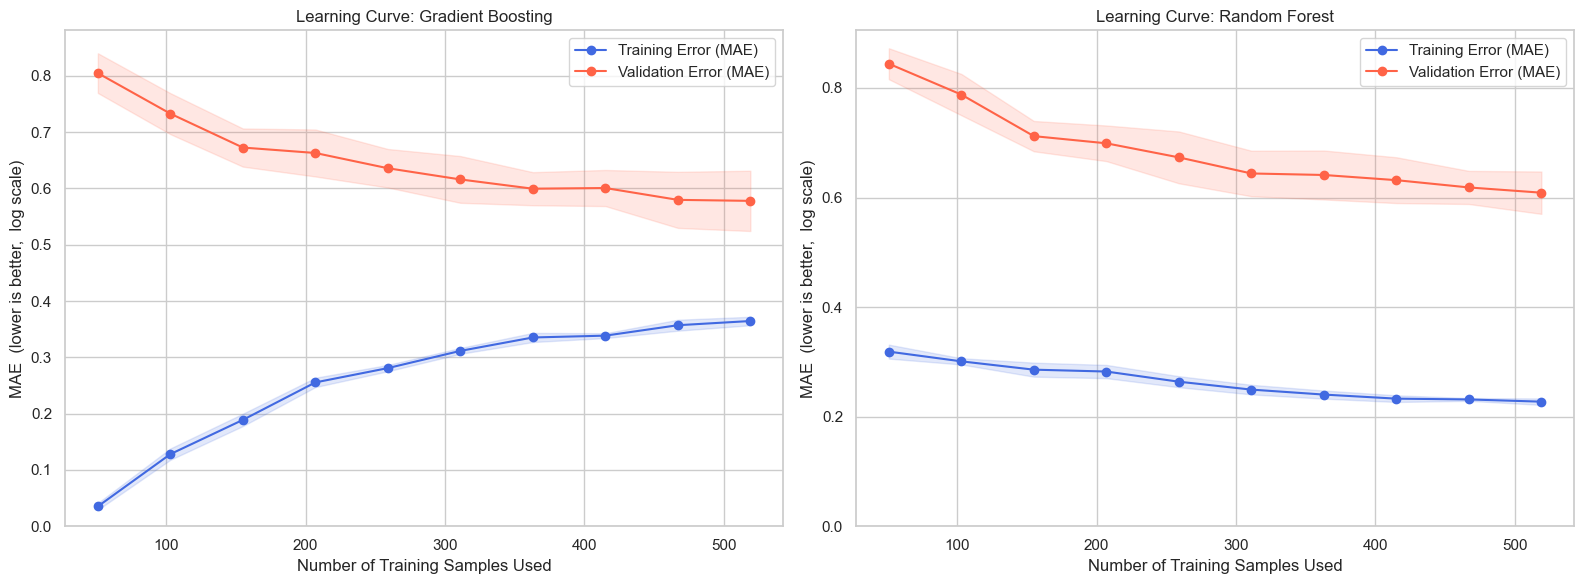

In [ ]:
# =============================================================================
# PHASE 5, STEP 1: Learning Curves
#
# A learning curve trains the model on progressively larger portions of the
# training data and records performance at each size.
#
# HOW TO READ:
#   Blue line  = Training error (how well the model fits its own data)
#   Red line   = Validation error (how well it performs on held-out folds)
#   Large gap  = Overfitting (model memorizes but does not generalize)
#   Both high  = Underfitting (model is too simple)
#   Converging and low = Good generalization
# =============================================================================

# Select the top 2 models by cross-validated R2 for the learning curve analysis
r2_scores = {name: np.mean(cv_results[name]["test_R2"]) for name in models}
top_two_names = sorted(r2_scores, key=r2_scores.get, reverse=True)[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, top_two_names):
    # Train the model on 10 different sizes (10% to 100% of training data)
    # and record training + validation error at each size
    train_sizes, train_scores, val_scores = learning_curve(
        models[name],
        X_train, y_train,
        cv=kf,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    # Convert negative MAE back to positive MAE for readability
    train_mae = -train_scores.mean(axis=1)
    val_mae   = -val_scores.mean(axis=1)
    train_std =  train_scores.std(axis=1)
    val_std   =  val_scores.std(axis=1)

    # Plot lines + shaded bands showing variability across folds
    ax.plot(train_sizes, train_mae, "o-", color="royalblue", label="Training Error (MAE)")
    ax.plot(train_sizes, val_mae,   "o-", color="tomato",    label="Validation Error (MAE)")
    ax.fill_between(train_sizes,
                    train_mae - train_std, train_mae + train_std,
                    alpha=0.15, color="royalblue")
    ax.fill_between(train_sizes,
                    val_mae   - val_std,   val_mae   + val_std,
                    alpha=0.15, color="tomato")
    ax.set_title(f"Learning Curve: {name}", fontsize=12)
    ax.set_xlabel("Number of Training Samples Used")
    ax.set_ylabel("MAE  (lower is better,  log scale)")
    ax.legend()
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


Best model by CV R2: Gradient Boosting  (R2 = 0.7278)
Generating validation curve for 'n_estimators' (number of trees)...



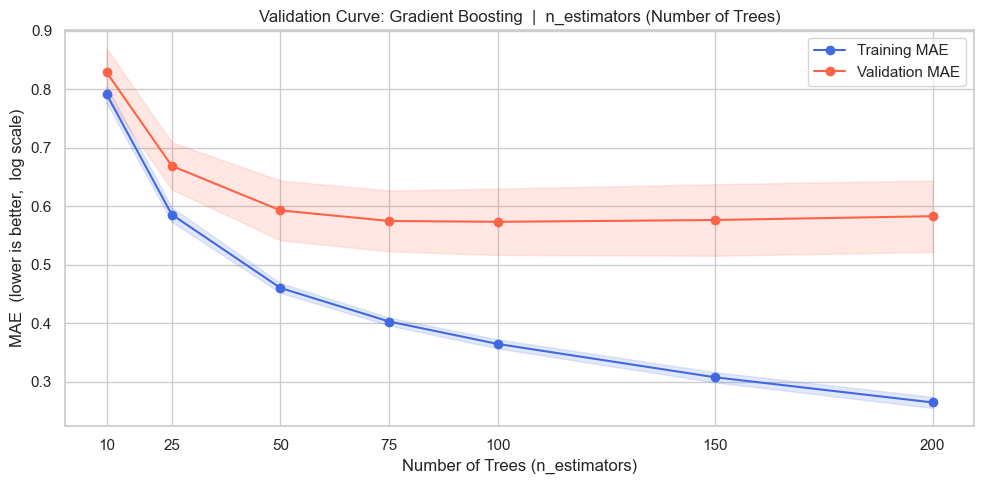

Optimal n_estimators based on validation MAE: 100
Beyond this value, adding more trees yields diminishing returns.


In [ ]:
# =============================================================================
# PHASE 5, STEP 2: Validation Curve for the Best Model
#
# A validation curve shows how performance changes as we vary ONE hyperparameter.
# This helps find the "sweet spot" — not too simple, not too complex.
# We examine n_estimators (number of trees) for the best-performing model.
# =============================================================================

best_model_name = max(r2_scores, key=r2_scores.get)
print(f"Best model by CV R2: {best_model_name}  (R2 = {r2_scores[best_model_name]:.4f})")
print(f"Generating validation curve for 'n_estimators' (number of trees)...\n")

param_range = [10, 25, 50, 75, 100, 150, 200]

# Train the best model with each value of n_estimators and record CV scores
train_scores_vc, val_scores_vc = validation_curve(
    models[best_model_name],
    X_train, y_train,
    param_name="model__n_estimators",  # "model__" because the estimator is inside a Pipeline
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

train_mae_vc = -train_scores_vc.mean(axis=1)
val_mae_vc   = -val_scores_vc.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mae_vc, "o-", color="royalblue", label="Training MAE")
plt.plot(param_range, val_mae_vc,   "o-", color="tomato",    label="Validation MAE")
plt.fill_between(param_range,
                 train_mae_vc - train_scores_vc.std(axis=1),
                 train_mae_vc + train_scores_vc.std(axis=1),
                 alpha=0.15, color="royalblue")
plt.fill_between(param_range,
                 val_mae_vc - val_scores_vc.std(axis=1),
                 val_mae_vc + val_scores_vc.std(axis=1),
                 alpha=0.15, color="tomato")
plt.title(f"Validation Curve: {best_model_name}  |  n_estimators (Number of Trees)")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("MAE  (lower is better,  log scale)")
plt.xticks(param_range)
plt.legend()
plt.tight_layout()
plt.show()

optimal_n = param_range[int(np.argmin(val_mae_vc))]
print(f"Optimal n_estimators based on validation MAE: {optimal_n}")
print("Beyond this value, adding more trees yields diminishing returns.")


In [ ]:
# =============================================================================
# PHASE 5, STEP 3: GridSearchCV on Random Forest
#
# GridSearchCV tries EVERY combination of the hyperparameter values we provide.
# Think of it like trying every key on a keychain one by one — exhaustive but thorough.
# Each combination is evaluated with cross-validation for a fair comparison.
#
# Parameter explanation:
#   n_estimators     — how many decision trees to build
#   max_depth        — how deep each tree is allowed to grow (None = no limit)
#   min_samples_leaf — minimum data points required at each leaf node
# =============================================================================

import time
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "model__n_estimators":     [50, 100, 200],
    "model__max_depth":        [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
}

# Total combinations: 3 x 3 x 3 = 27, each evaluated with 5-fold CV = 135 model fits
total_fits = (len(rf_param_grid["model__n_estimators"])
              * len(rf_param_grid["model__max_depth"])
              * len(rf_param_grid["model__min_samples_leaf"]) * 5)

print(f"Running GridSearchCV on Random Forest...")
print(f"Total model fits: {total_fits}  (27 combinations x 5 folds)")
print("This may take 2-5 minutes depending on your hardware.\n")

rf_grid = GridSearchCV(
    models["Random Forest"],
    rf_param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
rf_grid.fit(X_train, y_train)
print(f"Complete in {time.time() - t0:.1f} seconds.\n")

print("Best hyperparameters:")
for param, val in rf_grid.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {val}")
print(f"\nBest CV MAE (log scale): {-rf_grid.best_score_:.4f}")

# Store the best Random Forest pipeline for the comparison table and final evaluation
tuned_rf = rf_grid.best_estimator_


Running GridSearchCV on Random Forest...
Total model fits: 135  (27 combinations x 5 folds)
This may take 2-5 minutes depending on your hardware.

Complete in 3.9 seconds.

Best hyperparameters:
  max_depth                 20
  min_samples_leaf          1
  n_estimators              100

Best CV MAE (log scale): 0.6074


In [ ]:
# =============================================================================
# PHASE 5, STEP 4: RandomizedSearchCV on Gradient Boosting
#
# Instead of trying every combination (like GridSearchCV), RandomizedSearchCV
# randomly samples N combinations from a wide parameter space.
#
# This is much faster when there are many hyperparameters to tune, and
# typically finds a near-optimal configuration without exhaustive search.
# =============================================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

gb_param_dist = {
    "model__n_estimators":     randint(50, 301),   # Random integer: 50-300 boosting rounds
    "model__max_depth":        randint(2, 9),        # Random integer: 2-8 levels deep
    "model__learning_rate":    uniform(0.01, 0.29),  # Random float: 0.01-0.30
    "model__subsample":        uniform(0.6, 0.4),    # Random float: 0.60-1.00
    "model__min_samples_leaf": randint(1, 21),        # Random integer: 1-20
}

print("Running RandomizedSearchCV on Gradient Boosting...")
print("Randomly sampling 30 combinations from the parameter space.\n")

gb_random = RandomizedSearchCV(
    models["Gradient Boosting"],
    gb_param_dist,
    n_iter=30,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)

t0 = time.time()
gb_random.fit(X_train, y_train)
print(f"Complete in {time.time() - t0:.1f} seconds.\n")

print("Best hyperparameters:")
for param, val in gb_random.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {val}")
print(f"\nBest CV MAE (log scale): {-gb_random.best_score_:.4f}")

# Store the best Gradient Boosting pipeline
tuned_gb = gb_random.best_estimator_


Running RandomizedSearchCV on Gradient Boosting...
Randomly sampling 30 combinations from the parameter space.

Complete in 2.7 seconds.

Best hyperparameters:
  learning_rate             0.09644602972233707
  max_depth                 7
  min_samples_leaf          10
  n_estimators              78
  subsample                 0.9659151597581278

Best CV MAE (log scale): 0.5739


In [ ]:
# =============================================================================
# PHASE 5, STEP 5: Full Model Comparison Table
#
# We compare all 5 original models PLUS the 2 tuned models side by side.
# This is our final "leaderboard" — we select the best model based on R2 and MAE.
# =============================================================================

# Combine all models into one dictionary for comparison
all_models_to_compare = {
    **models,                               # Original 5 models from Phase 4
    "Random Forest (Tuned)":    tuned_rf,   # Best from GridSearchCV
    "Gradient Boosting (Tuned)": tuned_gb,  # Best from RandomizedSearchCV
}

# Cross-validate the two newly tuned models
# (the original 5 were already cross-validated in Phase 4)
print("Cross-validating the 2 tuned models for the comparison table...\n")
for name in ["Random Forest (Tuned)", "Gradient Boosting (Tuned)"]:
    results = cross_validate(
        all_models_to_compare[name],
        X_train, y_train,
        cv=kf,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_results[name] = results
    print(f"  {name} done.")

# --- Build the comparison DataFrame ---
rows = []
for name in all_models_to_compare:
    r = cv_results[name]
    mae_vals  = -r["test_neg_MAE"]
    rmse_vals =  np.sqrt(-r["test_neg_MSE"])
    r2_vals   =  r["test_R2"]
    rows.append({
        "Model":      name,
        "MAE mean":   round(mae_vals.mean(),  4),
        "MAE std":    round(mae_vals.std(),   4),
        "RMSE mean":  round(rmse_vals.mean(), 4),
        "RMSE std":   round(rmse_vals.std(),  4),
        "R2 mean":    round(r2_vals.mean(),   4),
        "R2 std":     round(r2_vals.std(),    4),
    })

comparison_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .sort_values("R2 mean", ascending=False)
)

print("\n=== MODEL COMPARISON TABLE  (5-Fold CV, log scale) ===")
print("Sorted by R2 mean — higher R2 is better, lower MAE/RMSE is better.\n")
print(comparison_df.to_string())

# Identify the best overall model
best_overall_name     = comparison_df["R2 mean"].idxmax()
best_overall_pipeline = all_models_to_compare[best_overall_name]

print(f"\n{'='*60}")
print(f"WINNER: {best_overall_name}")
print(f"  CV R2:    {comparison_df.loc[best_overall_name, 'R2 mean']}")
print(f"  CV MAE:   {comparison_df.loc[best_overall_name, 'MAE mean']}")
print(f"  CV RMSE:  {comparison_df.loc[best_overall_name, 'RMSE mean']}")
print(f"{'='*60}")


Cross-validating the 2 tuned models for the comparison table...

  Random Forest (Tuned) done.
  Gradient Boosting (Tuned) done.

=== MODEL COMPARISON TABLE  (5-Fold CV, log scale) ===
Sorted by R2 mean — higher R2 is better, lower MAE/RMSE is better.

                           MAE mean  MAE std  RMSE mean  RMSE std  R2 mean  R2 std
Model                                                                             
Gradient Boosting            0.5737   0.0566     0.7520    0.0584   0.7278  0.0345
Gradient Boosting (Tuned)    0.5739   0.0402     0.7616    0.0496   0.7210  0.0283
Random Forest (Tuned)        0.6074   0.0394     0.8049    0.0479   0.6880  0.0343
Random Forest                0.6080   0.0395     0.8056    0.0482   0.6874  0.0345
Bagging                      0.6088   0.0405     0.8066    0.0481   0.6866  0.0339
Extra Trees                  0.6802   0.0392     0.9092    0.0441   0.6026  0.0298
AdaBoost                     0.8451   0.0159     0.9804    0.0293   0.5375  0.0314


Fitting 'Gradient Boosting' on the full training set...

FINAL TEST PERFORMANCE: Gradient Boosting

  On log(y+1) scale  (used during training, consistent with CV):
    MAE:   0.5530
    RMSE:  0.7341
    R2:    0.7439

  On original scale  (actual donation counts — human-readable):
    MAE:   9.33 donations
    RMSE:  24.67 donations
    R2:    0.3865

  Interpretation:
    On average, predictions are off by ~9.3 donations.
    The model explains 38.6% of the variation in donation referrals.


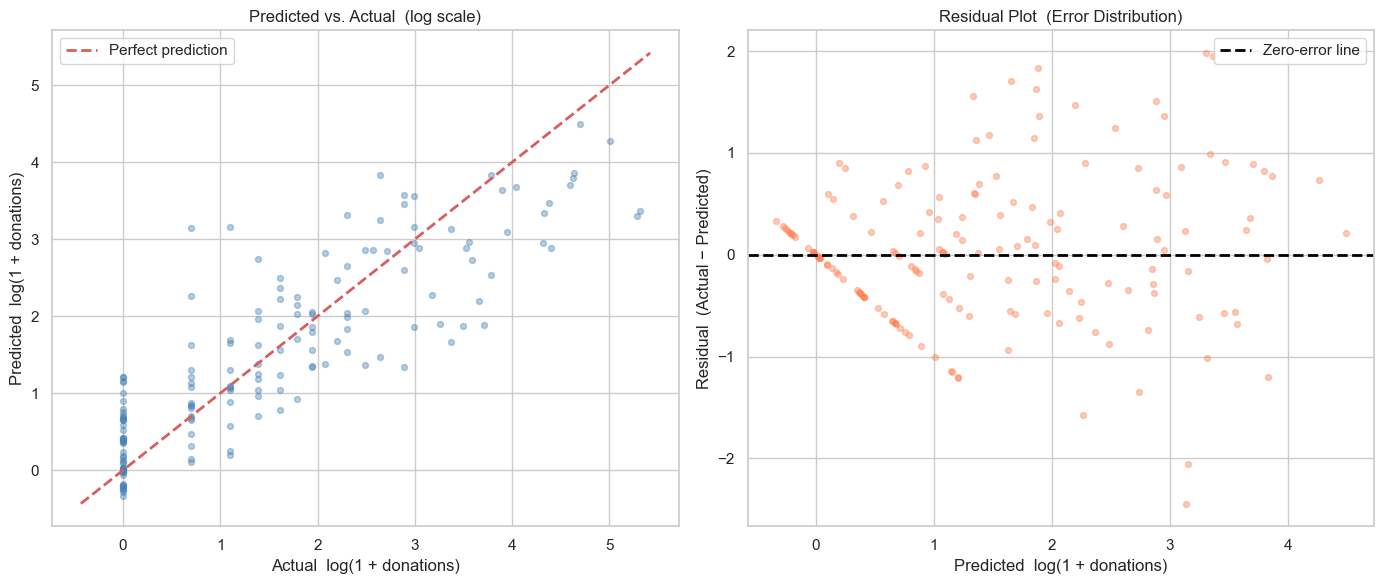

HOW TO READ THESE CHARTS:
  LEFT  — dots near the red line = accurate predictions
  RIGHT — random scatter around 0 = errors are random (good)
          visible curve or funnel = model has a systematic flaw (investigate)


In [ ]:
# =============================================================================
# PHASE 5, STEP 6: Final Evaluation on the Held-Out Test Set
#
# This is the "final exam." The model sees this 20% test set for the FIRST TIME.
# It was never used during training or cross-validation — so this score is an
# honest, unbiased measurement of real-world performance.
# =============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"Fitting '{best_overall_name}' on the full training set...")

# Fit the winning model on ALL training data before testing
best_overall_pipeline.fit(X_train, y_train)

# --- Predict on the held-out test set ---
y_pred_log = best_overall_pipeline.predict(X_test)

# --- Inverse-transform: convert log-scale predictions back to real donation counts ---
# np.expm1(x) = e^x - 1 reverses np.log1p(x) = log(1+x)
y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)  # clip: no negative donation counts
y_test_orig = np.expm1(y_test)                          # also reverse-transform true values

# --- Metrics on log scale (consistent with cross-validation) ---
mae_log  = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log   = r2_score(y_test, y_pred_log)

# --- Metrics on original scale (human-readable donation counts) ---
mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2_orig   = r2_score(y_test_orig, y_pred_orig)

print(f"\n{'='*60}")
print(f"FINAL TEST PERFORMANCE: {best_overall_name}")
print(f"{'='*60}")
print(f"\n  On log(y+1) scale  (used during training, consistent with CV):")
print(f"    MAE:   {mae_log:.4f}")
print(f"    RMSE:  {rmse_log:.4f}")
print(f"    R2:    {r2_log:.4f}")
print(f"\n  On original scale  (actual donation counts — human-readable):")
print(f"    MAE:   {mae_orig:.2f} donations")
print(f"    RMSE:  {rmse_orig:.2f} donations")
print(f"    R2:    {r2_orig:.4f}")
print(f"\n  Interpretation:")
print(f"    On average, predictions are off by ~{mae_orig:.1f} donations.")
print(f"    The model explains {r2_orig*100:.1f}% of the variation in donation referrals.")

# --- Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Predicted vs. Actual
# A perfect model would have all dots sitting on the red dashed line.
s_min = min(float(y_test.min()), float(y_pred_log.min())) - 0.1
s_max = max(float(y_test.max()), float(y_pred_log.max())) + 0.1
axes[0].scatter(y_test, y_pred_log, alpha=0.4, color="steelblue", s=18)
axes[0].plot([s_min, s_max], [s_min, s_max], "r--", lw=2, label="Perfect prediction")
axes[0].set_title("Predicted vs. Actual  (log scale)", fontsize=12)
axes[0].set_xlabel("Actual  log(1 + donations)")
axes[0].set_ylabel("Predicted  log(1 + donations)")
axes[0].legend()

# RIGHT: Residual Plot
# "Residual" = actual - predicted. Dots randomly scattered around 0 = good.
# A visible pattern (funnel, curve) = the model has systematic blind spots.
residuals = y_test.values - y_pred_log
axes[1].scatter(y_pred_log, residuals, alpha=0.4, color="coral", s=18)
axes[1].axhline(0, color="black", linestyle="--", lw=2, label="Zero-error line")
axes[1].set_title("Residual Plot  (Error Distribution)", fontsize=12)
axes[1].set_xlabel("Predicted  log(1 + donations)")
axes[1].set_ylabel("Residual  (Actual − Predicted)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("HOW TO READ THESE CHARTS:")
print("  LEFT  — dots near the red line = accurate predictions")
print("  RIGHT — random scatter around 0 = errors are random (good)")
print("          visible curve or funnel = model has a systematic flaw (investigate)")


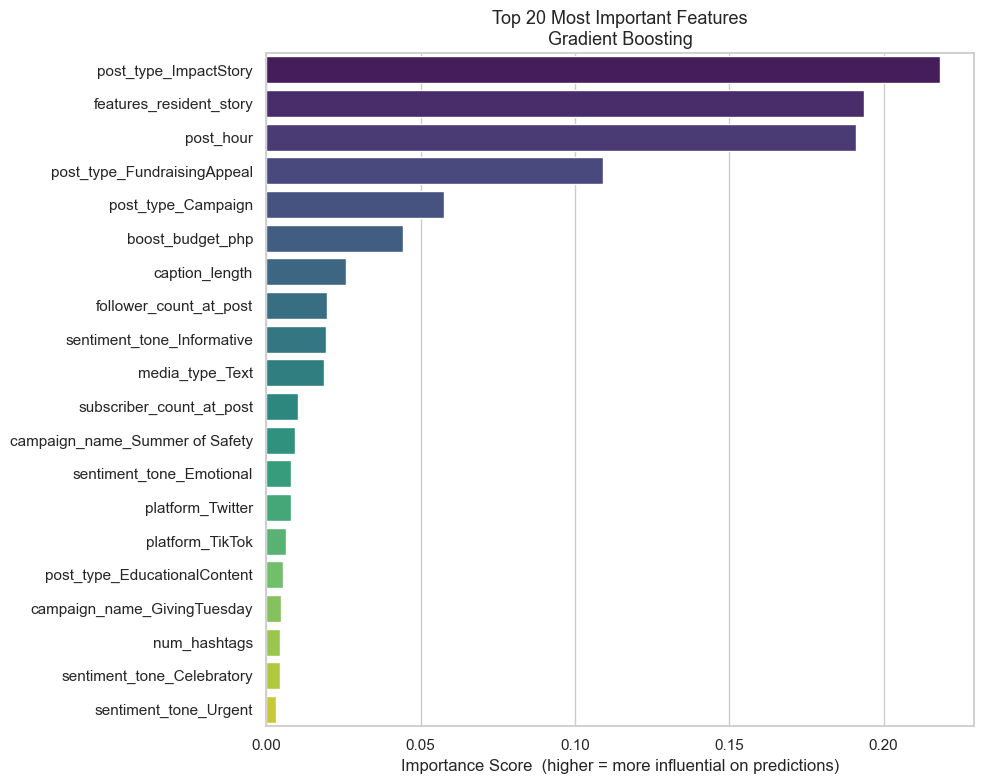

Top 10 most important features:
                    Feature  Importance
      post_type_ImpactStory    0.218342
    features_resident_story    0.193696
                  post_hour    0.190972
post_type_FundraisingAppeal    0.109139
         post_type_Campaign    0.057698
           boost_budget_php    0.044248
             caption_length    0.025974
     follower_count_at_post    0.019727
 sentiment_tone_Informative    0.019188
            media_type_Text    0.018697

INTERPRETATION:
  High-importance features are where content strategy should focus.
  Low-importance features have little effect on donation outcomes.


In [ ]:
# =============================================================================
# PHASE 5, STEP 7: Feature Importance
#
# Feature importance tells us which input features the model relied on most
# when making its predictions.
# This answers: "What actually drives donation referrals?"
# Higher importance = that feature had more influence on the model's output.
# =============================================================================

trained_model       = best_overall_pipeline.named_steps["model"]
fitted_preprocessor = best_overall_pipeline.named_steps["preprocessor"]

# --- Reconstruct feature names after one-hot encoding ---
# Numeric column names stay the same.
# Categorical columns expand: "platform" -> "platform_Facebook", "platform_Instagram", etc.
try:
    ohe_names = (
        fitted_preprocessor
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_cols)
        .tolist()
    )
    all_feat_names = numeric_cols + ohe_names
except Exception as e:
    print(f"Could not recover feature names automatically: {e}")
    all_feat_names = [f"feature_{i}" for i in range(len(trained_model.feature_importances_))]

if hasattr(trained_model, "feature_importances_"):
    feat_imp_df = (
        pd.DataFrame({
            "Feature":    all_feat_names,
            "Importance": trained_model.feature_importances_,
        })
        .sort_values("Importance", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Top 20 Most Important Features\n{best_overall_name}", fontsize=13)
    plt.xlabel("Importance Score  (higher = more influential on predictions)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    print("Top 10 most important features:")
    print(feat_imp_df.head(10).to_string(index=False))
    print()
    print("INTERPRETATION:")
    print("  High-importance features are where content strategy should focus.")
    print("  Low-importance features have little effect on donation outcomes.")
else:
    print(f"Note: '{best_overall_name}' does not natively expose feature importances.")
    print("Consider SHAP values (pip install shap) for detailed model explanation.")


# Phase 6: Deployment

The model is trained, evaluated, and ready to use. This final phase:

1. **Saves the model** to disk so it can be loaded without retraining
2. **Saves metadata** (feature names, performance metrics, configuration)
3. **Defines `predict_donations()`** — a reusable function that accepts any
   DataFrame of post details and returns predicted donation counts

### Generalization:
The `predict_donations()` function validates that all required columns are present
before running. If a column is missing, it raises a clear, descriptive error rather
than silently producing incorrect results. This makes the function safe to connect
to new datasets or a live database.

### Retraining:
As new data arrives, retraining is simple:
1. Update `DATA_PATH` in the Config cell (Cell 1)
2. Run the notebook from top to bottom
3. The new best model is automatically saved to `models/`


In [ ]:
# =============================================================================
# PHASE 6, STEP 1: Save the trained model and metadata to disk
# =============================================================================

import os
import joblib

# Create the models/ folder if it does not already exist
os.makedirs("models", exist_ok=True)

# --- Save the full pipeline (preprocessor + model) ---
# joblib.dump saves a Python object to a file, like zipping it up.
# We save the ENTIRE pipeline so that when it is loaded later, all the
# preprocessing steps (scaling, encoding) come with it automatically.
# No re-running of any transformation code is needed at inference time.
model_save_path = "models/social_media_donation_model.joblib"
joblib.dump(best_overall_pipeline, model_save_path)
print(f"Model saved:    {model_save_path}")

# --- Save model metadata ---
# This stores key information about the model so that other code
# (like a website dashboard) knows exactly what columns to provide.
model_metadata = {
    "model_name":        best_overall_name,
    "target_col":        TARGET_COL,
    "feature_cols":      feature_cols,      # Exact list of required input columns
    "numeric_cols":      numeric_cols,
    "categorical_cols":  categorical_cols,
    "cv_r2":             float(np.mean(cv_results[best_overall_name]["test_R2"])),
    "test_r2_log":       float(r2_log),
    "test_mae_log":      float(mae_log),
    "test_rmse_log":     float(rmse_log),
    "test_r2_original":  float(r2_orig),
    "test_mae_original": float(mae_orig),
}

metadata_save_path = "models/model_metadata.joblib"
joblib.dump(model_metadata, metadata_save_path)
print(f"Metadata saved: {metadata_save_path}")

# --- Quick verification: load and predict to confirm nothing is broken ---
print("\nVerifying saved model (predicting on 5 test samples)...")
loaded = joblib.load(model_save_path)
verify_preds = np.clip(np.expm1(loaded.predict(X_test.iloc[:5])), 0, None)
verify_actual = np.expm1(y_test.values[:5])

print(f"  Predicted donations: {np.round(verify_preds, 1)}")
print(f"  Actual donations:    {np.round(verify_actual, 1)}")
print("\nModel saved and verified successfully.")


Model saved:    models/social_media_donation_model.joblib
Metadata saved: models/model_metadata.joblib

Verifying saved model (predicting on 5 test samples)...
  Predicted donations: [1.9 4.1 1.  2.4 0.2]
  Actual donations:    [2. 3. 0. 1. 2.]

Model saved and verified successfully.


In [ ]:
# =============================================================================
# PHASE 6, STEP 2: predict_donations() — Reusable Inference Function
#
# This function is the public-facing interface for the model.
# Give it a DataFrame of post details (pre-publish features only),
# and it returns predicted donation counts as whole numbers.
#
# GENERALIZATION: Works with ANY dataset that has the required columns.
# If columns are missing, it raises a descriptive error rather than
# silently producing wrong results.
# =============================================================================

import joblib
import numpy as np
import pandas as pd


def predict_donations(
    df_new,
    model_path="models/social_media_donation_model.joblib",
    metadata_path="models/model_metadata.joblib",
):
    """
    Predict the number of donation referrals for one or more social media posts.

    Parameters
    ----------
    df_new : pd.DataFrame
        DataFrame with pre-publish post features. Required columns:
        platform, day_of_week, post_hour, post_type, media_type,
        num_hashtags, mentions_count, has_call_to_action, call_to_action_type,
        content_topic, sentiment_tone, caption_length, features_resident_story,
        campaign_name, is_boosted, boost_budget_php, follower_count_at_post,
        subscriber_count_at_post

    model_path : str
        Path to the saved joblib model pipeline.

    metadata_path : str
        Path to the saved model metadata.

    Returns
    -------
    pd.Series
        Predicted donation referral counts (non-negative whole numbers).
    """
    # Load the saved pipeline and metadata from disk
    pipeline      = joblib.load(model_path)
    metadata      = joblib.load(metadata_path)
    required_cols = metadata["feature_cols"]

    # --- Validate that all required columns exist ---
    # This is the generalization safety check. If the input DataFrame is
    # from a different dataset or is missing columns, we tell the user exactly
    # what is missing rather than crashing with a confusing internal error.
    missing_cols = [c for c in required_cols if c not in df_new.columns]
    if missing_cols:
        raise ValueError(
            f"The following required columns are missing from the input DataFrame:\n"
            f"  {missing_cols}\n\n"
            f"All required columns: {required_cols}"
        )

    # Select only the feature columns the model was trained on
    X_new = df_new[required_cols].copy()

    # Apply the same null-handling logic used during training
    if "boost_budget_php" in X_new.columns:
        X_new["boost_budget_php"] = X_new["boost_budget_php"].fillna(0)
    if "subscriber_count_at_post" in X_new.columns:
        X_new["subscriber_count_at_post"] = X_new["subscriber_count_at_post"].fillna(0)

    # Convert booleans to integers (same as training preprocessing)
    for col in X_new.select_dtypes(include=["bool"]).columns:
        X_new[col] = X_new[col].astype(int)

    # --- Run the full pipeline (preprocessor + model) ---
    # The pipeline automatically handles scaling, encoding, and imputation.
    # Predictions come out on the log(y+1) scale — we reverse-transform below.
    y_pred_log = pipeline.predict(X_new)

    # Reverse the log transform: expm1(x) = e^x - 1  (inverse of log1p)
    y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)

    # Round to the nearest whole number (donations are counted in whole numbers)
    y_pred_rounded = np.round(y_pred_orig).astype(int)

    return pd.Series(
        y_pred_rounded,
        index=df_new.index,
        name="predicted_donation_referrals",
    )


# =============================================================================
# DEMO: Run predict_donations() on a random sample of posts
# =============================================================================

print("=== DEMO: predict_donations() ===\n")

demo_source = pd.read_csv(DATA_PATH)
demo_sample = demo_source.sample(8, random_state=99)
demo_preds  = predict_donations(demo_sample)

demo_table = pd.DataFrame({
    "Platform":            demo_sample["platform"].values,
    "Post Type":           demo_sample["post_type"].values,
    "Media":               demo_sample["media_type"].values,
    "Day":                 demo_sample["day_of_week"].values,
    "Hour":                demo_sample["post_hour"].values,
    "Boosted":             demo_sample["is_boosted"].values,
    "Actual Donations":    demo_sample[TARGET_COL].values,
    "Predicted Donations": demo_preds.values,
    "Error (abs)":         abs(demo_sample[TARGET_COL].values - demo_preds.values),
})

print(demo_table.to_string(index=False))
print()
print("predict_donations() is ready for integration into the Lighthouse Sanctuary dashboard.")
print(f"\nSaved files:")
print(f"  models/social_media_donation_model.joblib  — the trained pipeline")
print(f"  models/model_metadata.joblib               — feature list and performance metrics")
print()
print("To retrain on new data: update DATA_PATH in Cell 1 and re-run the notebook.")


=== DEMO: predict_donations() ===

Platform          Post Type Media       Day  Hour  Boosted  Actual Donations  Predicted Donations  Error (abs)
LinkedIn        ImpactStory Photo  Saturday     9    False                74                   18           56
  TikTok           Campaign  Reel  Saturday    13    False                 1                    5            4
WhatsApp           ThankYou Photo  Saturday    11    False                 3                    2            1
Facebook           ThankYou Video   Tuesday    20    False                 2                    2            0
 Twitter        ImpactStory  Reel    Friday    16    False                 9                   13            4
LinkedIn EducationalContent  Text Wednesday     1    False                 0                    0            0
 YouTube           Campaign Video    Sunday     2    False                 0                    1            1
Facebook        ImpactStory Video   Tuesday    19    False                63 